# Dependecies

In [84]:
import os
import numpy as np
import torch
from torch import nn

from config import device, grad_clip, print_freq, pretrained_model_path
from data_gen import ArcFaceDataset
from focal_loss import FocalLoss
import shutil

import random
seed_value = 5
random.seed(seed_value)

import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,Dataset
import matplotlib.pyplot as plt
import torchvision.utils
import numpy as np
import random
from PIL import Image
import torch
from torch.autograd import Variable
import PIL.ImageOps    
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

from torch.optim.lr_scheduler import ReduceLROnPlateau

# Training Model Process

In [85]:
def imshow(img,text=None,should_save=False):
    npimg = img.numpy()
    plt.axis("off")
    if text:
        plt.text(75, 8, text, style='italic',fontweight='bold',
            bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()    

def show_plot(iteration,loss,title):
    plt.plot(iteration,loss)
    plt.title(title)
    plt.show()

In [ ]:
class Config():
    training_dir = "./dataset/train_face_set"
    testing_dir = "./dataset/test_face_set"
    train_batch_size = 32
    train_number_epochs = 5

In [87]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.125, contrast=0.125, saturation=0.125),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    'val': transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [88]:
class SiameseNetworkDataset(Dataset):
    
    def __init__(self, imageFolderDataset, transform=None):
        self.imageFolderDataset = imageFolderDataset    
        self.transform = transform
        
    def __getitem__(self, index):
        img0_tuple = random.choice(self.imageFolderDataset.imgs)
#         print(img0_tuple)
        #we need to make sure approx 50% of images are in the same class
        should_get_same_class = random.randint(0,1) 
        if should_get_same_class:
            while True:
                #keep looping till the same class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] == img1_tuple[1]:
                    break
        else:
            while True:
                #keep looping till a different class image is found
                
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] != img1_tuple[1]:
                    break

        img0 = Image.open(img0_tuple[0]).convert('RGB')
        img1 = Image.open(img1_tuple[0]).convert('RGB')


        if self.transform is not None:
            img0 = self.transform(img0)
            img1 = self.transform(img1)
        
        data = {}
        
        data['sample'] = img0
        data['frame'] = img1
        data['label'] = torch.from_numpy(np.array([int(img1_tuple[1] == img0_tuple[1])], dtype=np.float32))
        
        return data #img0, img1 , torch.from_numpy(np.array([int(img1_tuple[1] == img0_tuple[1])], dtype=np.float32))
        
    
    def __len__(self):
        return len(self.imageFolderDataset.imgs)

In [89]:
folder_dataset_train = dset.ImageFolder(root = Config.training_dir)
train_subset = SiameseNetworkDataset(imageFolderDataset = folder_dataset_train, transform = data_transforms['train'])

folder_dataset_test = dset.ImageFolder(root = Config.testing_dir)
val_subset = SiameseNetworkDataset(imageFolderDataset = folder_dataset_test, transform = data_transforms['val'])

print(f"Total Training Data: {len(train_subset)} image")
print(f"Total Validation/Test Data: {len(val_subset)} image")

Total Training Data: 93 image
Total Validation/Test Data: 25 image


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


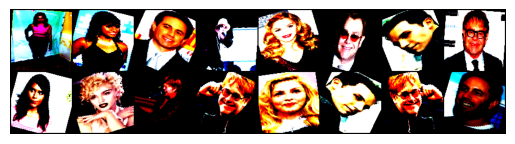

[[1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]]


In [90]:
vis_dataloader = DataLoader(train_subset, shuffle=True, num_workers = 0, batch_size = 8)

dataiter = iter(vis_dataloader)

example_batch = next(dataiter)
concatenated = torch.cat((example_batch['sample'], example_batch['frame']), 0)
imshow(torchvision.utils.make_grid(concatenated))
print(example_batch['label'].numpy())

In [91]:
class SiameseNetwork_test(nn.Module):

    def __init__(self, hidden_layer_neurons=256):
        super(SiameseNetwork_test, self).__init__()
        
        model_path = "./pretrained_model/mobilefacenet_scripted.pt"
        
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # sets device for model and PyTorch tensors
        
        
        self.backbone = torch.jit.load(model_path, map_location=self.device)
        for param in self.backbone.parameters():
            param.requires_grad = False
#         self.bn = nn.BatchNorm1d(num_features=128) # 128 because the output of mobilefacenet is 128 dimensional
        self.ln = nn.LayerNorm(128) # 128 because the output of mobilefacenet is 128 dimensional
        self.fc_classifier = nn.Sequential(
            nn.Linear(128, hidden_layer_neurons), # 1 hidden layer with 32 neurons
            nn.ReLU(),
#             nn.Linear(hidden_layer_neurons, hidden_layer_neurons//2), # 1 hidden layer with 32 neurons
#             nn.ReLU(),
#             nn.Dropout(p=0.5),
            nn.Linear(hidden_layer_neurons, 1),
            nn.Sigmoid()
        )
        self.mode = 'train' 
        

    def forward_once(self, x):
        output = self.backbone(x)
#         output = self.bn(output)
        output = self.ln(output)
        print("Mean : {}".format(output[1].mean()))
        print("Std : {}".format(output[1].std()))
        return output
    
    def forward_train(self, data : dict):
        input1 = data['sample'].to(self.device)
        input2 = data['frame'].to(self.device)
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
#         output = torch.cat((output1, output2), 1)
        output = output1 - output2 # difference
        output = self.ln(output) # normalization
        
        return output
    
    def forward_test(self, image):
        image = image.to(self.device)
        output2 = self.forward_once(image)
#         output = torch.cat((self.sample, output2), 1) # concatenation 
        output = self.sample - output2 # difference
        output = self.ln(output) # normalization
        return output

    
    def forward(self, data):
        if self.mode == 'test':
            output = self.forward_test(data)
        else:
            output= self.forward_train(data)
        
        output = self.fc_classifier(output)
        return output
    
    def init(self, images): # initialization of sample images
        images = images.to(self.device)
        samples = self.forward_once(images)
        if samples.shape[0] == 1:
            self.sample = samples
        else:
            self.sample = samples.mean(axis=0).unsqueeze(0)

In [92]:
net = SiameseNetwork_test()
net = net.to(device)
net(example_batch)

Mean : 3.725290298461914e-09
Std : 1.0039273500442505
Mean : 3.725290298461914e-09
Std : 1.0039275884628296


tensor([[0.4696],
        [0.4685],
        [0.5280],
        [0.5100],
        [0.4087],
        [0.4621],
        [0.5075],
        [0.5017]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [93]:
########### concatenation
# concatenation of output from simaese network
class SiameseNetwork(nn.Module):

    def __init__(self, hidden_layer_neurons = 256 ):
        super(SiameseNetwork, self).__init__()
        model_path = "./pretrained_model/mobilefacenet_scripted.pt"
    
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # sets device for model and PyTorch tensors
        
        self.backbone = torch.jit.load(model_path, map_location=self.device)
        for param in self.backbone.parameters():
            param.requires_grad = False
#         self.bn = nn.BatchNorm1d(num_features=128) # 128 because the output of mobilefacenet is 128 dimensional
#         self.ln = nn.LayerNorm(128) # 128 because the output of mobilefacenet is 128 dimensional
        self.fc_classifier = nn.Sequential(
            nn.Linear(256, hidden_layer_neurons), # 1 hidden layer with 32 neurons
            nn.ReLU(),
#             nn.Linear(hidden_layer_neurons, hidden_layer_neurons//2), # 1 hidden layer with 32 neurons
#             nn.ReLU(),
#             nn.Dropout(p=0.5),
            nn.Linear(hidden_layer_neurons, 1),
            nn.Sigmoid()
        )
        self.mode = 'train' 
        

    def forward_once(self, x):
        output = self.backbone(x)
#         output = self.ln(output)
#         output = self.bn(output)
        return output
    
    def forward_train(self, data : dict):
        input1 = data['sample'].to(self.device)
        input2 = data['frame'].to(self.device)
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        output = torch.cat((output1, output2), 1)
        return output
    
    def forward_test(self, image):
        image = image.to(self.device)
        output2 = self.forward_once(image)
        output = torch.cat((self.sample, output2), 1)
        return output

    
    def forward(self, data):
        if self.mode == 'test':
            output = self.forward_test(data)
        else:
            output= self.forward_train(data)
        
        output = self.fc_classifier(output)
        return output
    
    def init(self, images): # initialization of sample images
        images = images.to(self.device)
        samples = self.forward_once(images)
        if samples.shape[0] == 1:
            self.sample = samples
        else:
            self.sample = samples.mean(axis=0).unsqueeze(0)

In [94]:
net = SiameseNetwork()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam([{'params': net.fc_classifier.parameters()}], lr = 0.001)
scheduler = ReduceLROnPlateau(optimizer, factor=0.5)
# net = nn.DataParallel(net)
net = net.to(device)

In [95]:
train_dataloader = DataLoader(train_subset, shuffle=True, num_workers=0, batch_size=Config.train_batch_size)
val_dataloader = DataLoader(val_subset, shuffle=False, num_workers=0, batch_size=Config.train_batch_size)

In [96]:
def save_checkpoint(state, is_best, filename='classifier_model/checkpoint.tar'):
    torch.save(state, filename)
    if is_best:
        print("Saving the best model !")
        shutil.copyfile(filename, 'classifier_model/classifier.tar')

In [97]:
from sklearn.metrics import accuracy_score, confusion_matrix
def calculate_accuracy(probs, label):
    label = label.cpu()
    pred = [0 if i.item() < 0.5 else 1 for i in probs]
    
    acc = accuracy_score(label, pred)
    tn, fp, fn, tp = confusion_matrix(label, pred).ravel()
    return [acc, tp, tn, fp, fn]

In [98]:
counter = []
loss_history = [] 
acc_history = []
val_loss_history = []
val_acc_history = []
best_loss = np.inf
iteration_number = 0
check_every = 10

for epoch in range(0, Config.train_number_epochs):
    for i, data in enumerate(train_dataloader, 0):
        label = data['label'].to(device)
        optimizer.zero_grad()
        output_prob = net(data)
        
        bce_loss = criterion(output_prob, label)
        
        epoch_acc = calculate_accuracy(output_prob, label)[0] # 0th is the accuracy

        train_tp, train_tn, train_fp, train_fn = calculate_accuracy(output_prob, label)[1:]
        bce_loss.backward()
        optimizer.step()

        
        if i % check_every == 0:
            
            valid_loss = 0.0
            valid_acc = 0.0
            valid_tp, valid_tn, valid_fp, valid_fn = 0.0, 0.0, 0.0, 0.0
            with torch.no_grad():
                net.eval()
                for val_data in val_dataloader:
                    val_label = val_data['label'].to(device)
                    val_output = net(val_data)
                    val_loss = criterion(val_output, val_label)
                    
                    valid_loss += val_loss
                    val_res = calculate_accuracy(val_output, val_label)
                    valid_acc += val_res[0]
                    valid_tp += val_res[1]
                    valid_tn += val_res[2]
                    valid_fp += val_res[3]
                    valid_fn += val_res[4]
                    
            
            val_loader_length =  len(val_dataloader)
            validation_loss = valid_loss /val_loader_length
            validation_acc = valid_acc / val_loader_length
            validation_tp, validation_tn = int(valid_tp/val_loader_length), int(valid_tn/val_loader_length)
            validation_fp, validation_fn = int(valid_fp/val_loader_length), int(valid_fn/val_loader_length)
            
            print("Epoch #{}\t Train loss {:.3f}\t Train Acc {:.3f}\t Val Loss {:.3f}\t Val Acc {:.3f}".format(epoch,
                                                                                       bce_loss.item(),
                                                                                       epoch_acc, 
                                                                                       validation_loss, 
                                                                                       validation_acc))
            print("Train TP {}\t TN {}\t FP {}\t FN {}\t Valid TP {}\t TN {}\t FP {}\t FN {}\n".format(
                train_tp, 
                train_tn, 
                train_fp, 
                train_fn, 
                validation_tp, 
                validation_tn, 
                validation_fp, 
                validation_fn))

            
            
            iteration_number += check_every
            counter.append(iteration_number)
            loss_history.append(bce_loss.item())
            acc_history.append(epoch_acc)
            
            val_loss_history.append(validation_loss.item())
            val_acc_history.append(validation_acc)
            scheduler.step(validation_loss)
            is_best = validation_loss < best_loss
            best_loss = min(validation_loss, best_loss)
            save_checkpoint({
                'epoch': epoch + 1,
                'weights': net.state_dict(),
                'best_loss': best_loss,
                'optimizer' : optimizer.state_dict(),
            }, is_best)
            net.train()

Epoch #0	 Train loss 0.667	 Train Acc 0.562	 Val Loss 0.704	 Val Acc 0.520
Train TP 7	 TN 11	 FP 5	 FN 9	 Valid TP 13	 TN 0	 FP 10	 FN 2

Saving the best model !
Epoch #1	 Train loss 0.709	 Train Acc 0.375	 Val Loss 0.721	 Val Acc 0.400
Train TP 7	 TN 5	 FP 6	 FN 14	 Valid TP 5	 TN 5	 FP 5	 FN 10

Epoch #2	 Train loss 0.705	 Train Acc 0.469	 Val Loss 0.703	 Val Acc 0.520
Train TP 6	 TN 9	 FP 11	 FN 6	 Valid TP 2	 TN 11	 FP 1	 FN 11

Saving the best model !
Epoch #3	 Train loss 0.675	 Train Acc 0.469	 Val Loss 0.787	 Val Acc 0.320
Train TP 8	 TN 7	 FP 7	 FN 10	 Valid TP 2	 TN 6	 FP 10	 FN 7

Epoch #4	 Train loss 0.745	 Train Acc 0.438	 Val Loss 0.712	 Val Acc 0.400
Train TP 10	 TN 4	 FP 10	 FN 8	 Valid TP 2	 TN 8	 FP 6	 FN 9



In [99]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

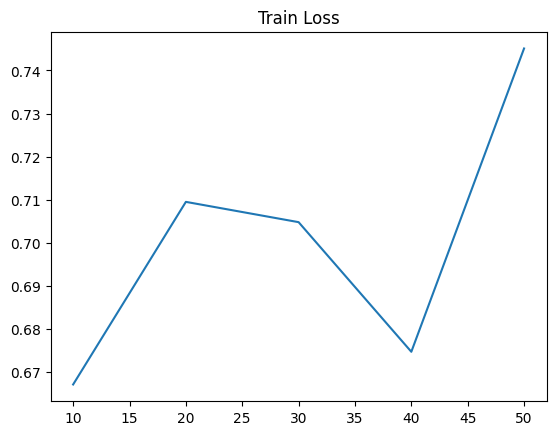

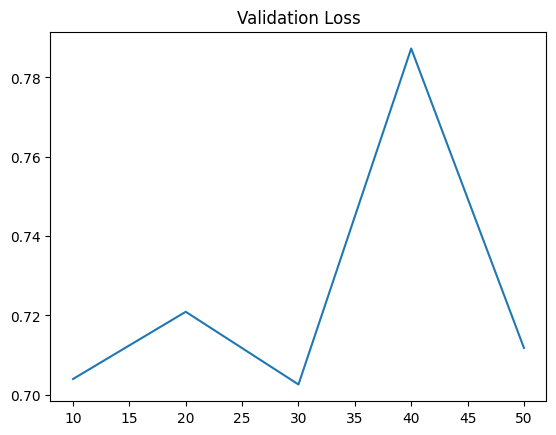

In [100]:
show_plot(counter, loss_history, "Train Loss")
show_plot(counter, val_loss_history, "Validation Loss")

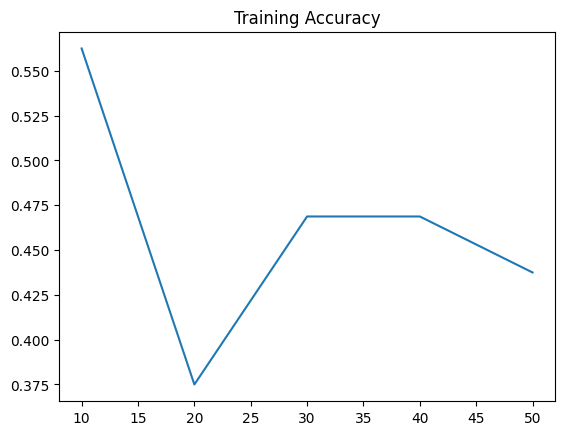

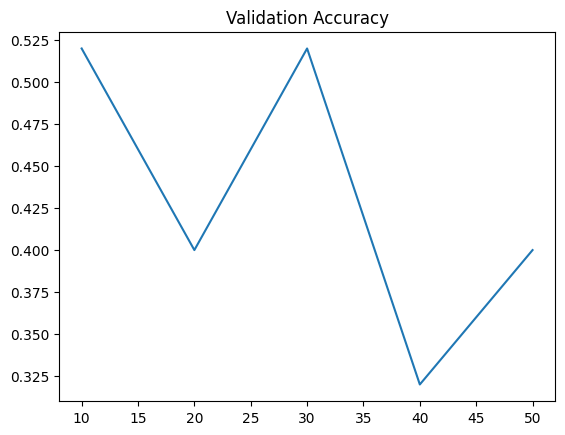

In [101]:
show_plot(counter, acc_history, "Training Accuracy")
show_plot(counter, val_acc_history, "Validation Accuracy")

### Loading the trained network 

In [102]:
test_folder = dset.ImageFolder(root=Config.testing_dir)
test_dataset = SiameseNetworkDataset(imageFolderDataset = test_folder, transform = data_transforms['val'])
test_loader = DataLoader(test_dataset, shuffle=False, num_workers=0, batch_size=Config.train_batch_size)

In [103]:
classifier = SiameseNetwork().to(device=device)
# classifier = nn.DataParallel(classifier)
classifier_model_path=  'classifier_model/classifier.tar'
classifier.load_state_dict(torch.load(classifier_model_path)['weights'])

<All keys matched successfully>

In [105]:
with torch.no_grad():
    classifier.eval()
    test_loss, test_acc, test_tp, test_tn, test_fp, test_fn = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    for data in test_loader:
        label = data['label'].to(device)
        output = classifier(data)
        loss = criterion(output, label)
        test_loss += loss.item()
        res = calculate_accuracy(output, label)
        test_acc += res[0]
        test_tp += res[1]
        test_tn += res[2]
        test_fp += res[3]
        test_fn += res[4]

L = len(test_loader) 
test_loss, test_acc, test_tp, test_tn, test_fp, test_fn = test_loss/L, test_acc/L, test_tp/L, test_tn/L, test_fp/L, test_fn/L
print("Test Loss : {}".format(test_loss))
print("Test Acc : {}".format(test_acc))
print("Test TP : {}".format(test_tp))
print("Test TN : {}".format(test_tn))
print("Test FP : {}".format(test_fp))
print("Test FN : {}".format(test_fn))

print(f"Epoch: ", epoch)


Test Loss : 0.673529326915741
Test Acc : 0.52
Test TP : 10.0
Test TN : 3.0
Test FP : 9.0
Test FN : 3.0
Epoch:  4
